In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import sys
import pickle

from datetime import datetime, timedelta
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
from upsetplot import UpSet, from_contents

import functools

from cest_dates_enums import is_cest_start, is_cest_end

### Helper functions

In [55]:
def get_pickle_data(pickle_path, function, params=None):
    if os.path.exists(pickle_path):
        with open(pickle_path, 'rb') as file:
            data = pickle.load(file)
    else:
        data = function(*params)
        with open(pickle_path, 'wb') as f:
            pickle.dump(data, f)
    return data

In [145]:
def plot_histogram_with_stats_regular(values, title='Histogram', bins='auto', density=False, x_range=None, x_label="Value", y_label="Frequency"):
    """
    Generate a histogram from a list of values and display a stats box.

    Parameters:
    - values: list or array of numeric data
    - title: title of the plot
    - bins: number of histogram bins
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    min_val = np.min(values)
    max_val = np.max(values)

    if x_range is None:
        x_range = (min_val, max_val)

    # Clip values so that everything above x_range[1] falls into the last bin,
    # and everything below x_range[0] into the first bin.
    #clipped = np.clip(values, x_range[0], x_range[1])

    # Plot histogram using the clipped data
    ax.hist(values, bins=bins, density=density, range=x_range,
            color='skyblue', edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    # Stats computed on the original values (not clipped)
    mean_val = np.mean(values)
    std_val = np.std(values)

    stats_lines = [
        f"Min: {min_val:.2f}",
        f"Max: {max_val:.2f}",
        f"Mean: {mean_val:.2f}",
        f"Std: {std_val:.2f}"
    ]
    stats_text = "\n".join(stats_lines)
    
    # Determine font size based on number of stats lines
    font_size = 10

    # Add stats box to the plot
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes, ha='right', va='top',
            verticalalignment='top', bbox=dict(boxstyle='round',
            facecolor='wheat', alpha=0.8), fontsize=font_size)
    
    plt.tight_layout()

    plt.show()


# Data Exploration
Raw recieved data from `zasilka-TP4VGT9M89DDMFIM` are split and concatenated in such a way so we now I a .csv file per one water meter (per id).

Script `split_and_concat_dfs.py` is used for this purpose.

Finished data is in `data` folder.

In this notebook data will be examined.

## Example Water Meter 

In [57]:
#example_df = pd.read_csv("./data/2328.csv")
#example_df.tail()

In [58]:
#example_df.info()

## Number of Water Meters

In [59]:
all_dfs_paths = [f"./data_w_diff_001/{filename}" for filename in os.listdir('./data_w_diff_001')] 
print(f"Total number of Water Meters: {len(all_dfs_paths)}")

Total number of Water Meters: 27603


## Timestamp not sorted
We see that some timestamp values are not sorted, let's examine that

### Check Sorting
Check if all values in `timestamp` and `hodnota` column are sorted.

We sort all df based on `timestamp` but many values stay unsorted based on `hodnota`. Let examine them

In [60]:
def get_unsorted_filepaths_timestamp(folder = './data'):

    unsorted_filepaths_timestamp_indeces = {}

    for filename in os.listdir(folder):
        if filename.endswith('.csv'):
            filepath = os.path.join(folder, filename)                
            df = pd.read_csv(filepath)

            timestamp_col = 'timestamp'
            df[timestamp_col] = pd.to_datetime(df[timestamp_col])

            unsorted_indices = df.index[df[timestamp_col].diff() < pd.Timedelta(0)].tolist()

            unsorted_indeces = []
            for idx in unsorted_indices:
                unsorted_indeces.append(idx)

            if unsorted_indeces:
                unsorted_filepaths_timestamp_indeces[filepath] = unsorted_indeces

    return unsorted_filepaths_timestamp_indeces

In [61]:
unsorted_filepaths_timestamp = get_pickle_data('./pickles/unsorted_filepaths_timestamp.pkl', get_unsorted_filepaths_timestamp, ['./data'])
print(f"Number of files that contain unsorted timestamp: {len(unsorted_filepaths_timestamp)}")
total_indeces_unsorted = sum(len(v) for v in unsorted_filepaths_timestamp.values())
print(f"Number of total unsorted indeces: {total_indeces_unsorted}")

Number of files that contain unsorted timestamp: 3710
Number of total unsorted indeces: 7592


In [62]:
def get_unsorted_filepaths_timestamp_and_hodnota(unsorted_filepaths_timestamp):
    unsorted_filepaths_timestamp_and_hodnota = {}
    
    for filepath in unsorted_filepaths_timestamp:
        df = pd.read_csv(filepath)

        timestamp_col = 'timestamp'
        df[timestamp_col] = pd.to_datetime(df[timestamp_col])

        unsorted_indices = df.index[df[timestamp_col].diff() < pd.Timedelta(0)].tolist()

        unsorted_hodnota_indeces = []
        for idx in unsorted_indices:
            if df.iloc[idx-1]['hodnota'] - df.iloc[idx]['hodnota'] <= 0:
                unsorted_hodnota_indeces.append(idx)
                #print(df.iloc[idx-1:idx+1])

        if unsorted_hodnota_indeces:
            unsorted_filepaths_timestamp_and_hodnota[filepath] = unsorted_hodnota_indeces
        
    return unsorted_filepaths_timestamp_and_hodnota

In [63]:
unsorted_filepaths_timestamp_and_hodnota = get_pickle_data('./pickles/unsorted_filepaths_timestamp_and_hodnota.pkl', get_unsorted_filepaths_timestamp_and_hodnota, [list(unsorted_filepaths_timestamp.keys())])

print(f"Number of files that contain unsorted timestamp where also the hodnota doesn't match: {len(unsorted_filepaths_timestamp_and_hodnota)}")
total_indices = sum(len(v) for v in unsorted_filepaths_timestamp_and_hodnota.values())
print(f"Total number of indices: {total_indices}")

Number of files that contain unsorted timestamp where also the hodnota doesn't match: 3706
Total number of indices: 7585


In [64]:
#i = 0
#for filepath, indices in unsorted_filepaths_timestamp_and_hodnota.items():
#    df = pd.read_csv(filepath)
#    for idx in indices:
#        print(df.iloc[idx])
#    if i > 10:
#        break
#    i += 1

### Is it only when CEST changes

In [65]:
def get_cest_end_indeces(unsorted_filepaths_timestamp):
    cest_end_filepath_indeces = {}
        
    for filepath in unsorted_filepaths_timestamp:
        df = pd.read_csv(filepath)

        timestamp_col = 'timestamp'
        df[timestamp_col] = pd.to_datetime(df[timestamp_col])

        unsorted_indices = df.index[df[timestamp_col].diff() < pd.Timedelta(0)].tolist()

        cest_end_indeces = []
        for idx in unsorted_indices:
            if is_cest_end(df.iloc[idx]['timestamp']):
                cest_end_indeces.append(idx)

        if cest_end_indeces:
            cest_end_filepath_indeces[filepath] = cest_end_indeces
            
    return cest_end_filepath_indeces            

### When timestamp ins not sorted but its not CEST
since this is only occuring in 2 files

In [66]:
#for filepath in unsorted_filepaths_timestamp:
#    
#    if filepath in cest_end_filepath_indeces:
#        continue
#    df = pd.read_csv(filepath)
#
#    timestamp_col = 'timestamp'
#    df[timestamp_col] = pd.to_datetime(df[timestamp_col])
#    
#    unsorted_indices = df.index[df[timestamp_col].diff() < pd.Timedelta(0)].tolist()
#    
#    for idx in unsorted_indices:
#        print(df.iloc[idx-1:idx+1])
    

### Timestamp not being sorted CEST reason
Since timestamp only looks not being sorted. It actually is but when we switch form summer to winter time we set the time 1h back so it looks like the timestamp is not sorted.

## Check how `hodnota` is sorted

In [67]:
def get_unsorted_filepaths_hodnota(folder = './data', diff = 0):

    unsorted_filepaths_hodnota_indeces = {}

    for filename in os.listdir(folder):
        if filename.endswith('.csv'):
            filepath = os.path.join(folder, filename)                
            df = pd.read_csv(filepath)
            
            unsorted_indices = df.index[df['hodnota'].diff() < diff].tolist()

            unsorted_indeces = []
            for idx in unsorted_indices:
                unsorted_indeces.append(idx)

            if unsorted_indeces:
                unsorted_filepaths_hodnota_indeces[filepath] = unsorted_indeces

    return unsorted_filepaths_hodnota_indeces

In [68]:
unsorted_filepaths_hodnota_indeces = get_pickle_data('./pickles/unsorted_filepaths_hodnota_indeces.pkl', get_unsorted_filepaths_hodnota, ['./data', 0])

print(f"Number of files that have unsorted hodnota: {len(unsorted_filepaths_hodnota_indeces)}")
total_indeces_unsorted_hodnota = sum(len(v) for v in unsorted_filepaths_hodnota_indeces.values())
print(f"Number of indices that are unsorted {total_indeces_unsorted_hodnota}")

Number of files that have unsorted hodnota: 6536
Number of indices that are unsorted 293760


In [69]:
unsorted_filepaths_hodnota_indeces_diff_001 = get_pickle_data('./pickles/unsorted_filepaths_hodnota_indeces_diff_001.pkl', get_unsorted_filepaths_hodnota, ['./data', -0.002])

print(f"Number of files that have unsorted hodnota if we allow 0.001 diff: {len(unsorted_filepaths_hodnota_indeces_diff_001)}")
total_indeces_unsorted_hodnota_diff_001 = sum(len(v) for v in unsorted_filepaths_hodnota_indeces_diff_001.values())
print(f"Number of indices that are unsorted {total_indeces_unsorted_hodnota_diff_001}")

Number of files that have unsorted hodnota if we allow 0.001 diff: 5210
Number of indices that are unsorted 158115


Since we havent managed to figure out how to deal with the unsorted `hodnota` values the `Diff` values are calculated regardless but when the value would be negative a NaN value is added.

## Create Diff

`Diff` column in added in `create_diff.py` file.

Create column with values equal to `df[hodnota][t]` - `df[hodnota][t-1]`.

Since we havent managed to figure out how to deal with the unsorted `hodnota` values the `Diff` values are calculated regardless but when the value would be negative a NaN value is added.

In [70]:
example_df = pd.read_csv('./data_w_diff_001/111227.csv')
example_df.head()

,id,timestamp,hodnota,Diff,timestamp_utc
0,111227,2022-04-21 05:03:01,0.200,0.000,2022-04-21 03:03:01+00:00
1,111227,2022-04-25 16:46:32,38.142,37.942,2022-04-25 14:46:32+00:00
2,111227,2022-04-25 17:46:49,38.568,0.426,2022-04-25 15:46:49+00:00
3,111227,2022-04-25 19:47:24,39.679,1.111,2022-04-25 17:47:24+00:00
4,111227,2022-04-25 22:48:17,42.142,2.463,2022-04-25 20:48:17+00:00


## Add Metadata

New folder called `metadata` created where metadata (json files) are placed. Each file has the same name as a corresponding water meter ID.

Metadata are created in file `create_metadata.py`

In [71]:
import json

with open("metadata_001/111227.json", 'r') as f:
    example_metadata = json.load(f)
    
print(example_metadata)

{'num_records': 9288, 'start_time': '2022-04-21 05:03:01', 'end_time': '2025-10-07 23:17:49', 'value_min': 0.2, 'value_max': 10355.422, 'value_mean': 4633.054635874247, 'value_std': 3414.5943346175854, 'diff_min': 0.0, 'diff_max': 320.029, 'diff_mean': 1.1149033161068045, 'diff_std': 5.182698632616613, 'nan_value_count': 0, 'nan_diff_count': 0, 'common_periodicity_seconds': 3617.0, 'num_gaps_5min': 4224, 'num_gaps_10percent': 4222, 'proportion_of_gaps_5min': 0.45478036175710596, 'proportion_of_gaps_10percent': 0.4545650301464255, 'common_periodicity_top_10': [3617.0], 'na_timestamp_utc_count': 1}


## Number of Records
Histogram of number of records

In [72]:
def metadata_to_list(key_name, folder='./metadata_001') -> list:
    '''
    Returns a list with metadata values of a given key values in parameter
    '''
    res = []
    
    for json_file in os.listdir(folder):
        json_path = os.path.join(folder, json_file)
        try:
            with open(json_path, 'r') as f:
                metadata =  json.load(f)
        except json.JSONDecodeError as e:
            print(f"Error decoding JSON file {json_path}: {e}", file=sys.stderr)
            raise
        
        res.append(metadata[key_name])
    
    return res

def metadata_to_dict(key_name, folder='./metadata_001') -> dict:
    '''
    Returns a dict with metadata values of a given key values in parameter
    '''
    res = {}
    
    for json_file in os.listdir(folder):
        json_path = os.path.join(folder, json_file)
        try:
            with open(json_path, 'r') as f:
                metadata =  json.load(f)
        except json.JSONDecodeError as e:
            print(f"Error decoding JSON file {json_path}: {e}", file=sys.stderr)
            raise
        
        res[json_file] = metadata[key_name]
    
    return res

In [123]:
number_of_records = get_pickle_data('./pickles/number_of_records_001', metadata_to_list, ['num_records'])

In [124]:
print(f"Total number of records: {sum(number_of_records)}")

Total number of records: 618151262


In [ ]:
def plot_histogram_with_stats(values, title='Histogram', bins='auto', density=False,
                               x_range=None, x_label="Value", y_label="Frequency"):
    values = np.asarray(values)
    min_val = np.min(values)
    max_val = np.max(values)

    if x_range is None:
        x_range = (min_val, max_val)

    range_min, range_max = x_range

    in_range = values[values <= range_max]
    overflow = values[values > range_max]

    fig, ax = plt.subplots(figsize=(8, 6))

    _, bin_edges = np.histogram(in_range, bins=bins, range=(range_min, range_max))
    bin_width = bin_edges[1] - bin_edges[0]

    ax.hist(in_range, bins=bin_edges, density=density,
            color='skyblue', edgecolor='black')

    overflow_x = range_max + bin_width / 2
    overflow_count = len(overflow)
    overflow_height = (overflow_count / (len(values) * bin_width)) if density else overflow_count

    ax.bar(overflow_x, overflow_height, width=bin_width * 0.95,
           color='skyblue', edgecolor='black', linewidth=0.8)

    ax.set_xlim(range_min, range_max + bin_width * 1.55)

    # Let matplotlib place nice auto ticks over the normal range,
    # then append just the one overflow tick
    ax.xaxis.set_major_locator(plt.MaxNLocator(nbins='auto', steps=[1,2,5,10]))
    fig.canvas.draw()  # force tick computation before we read them

    auto_ticks = [t for t in ax.get_xticks()
                  if range_min <= t <= range_max and not np.isclose(t, range_max, atol=bin_width * 0.6)]
    tick_positions = auto_ticks + [overflow_x]
    tick_labels = [f'{t:g}' for t in auto_ticks] + [f'≥{range_max:g}']

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right')

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    mean_val = np.mean(values)
    std_val = np.std(values)
    stats_lines = [
        f"Min: {min_val:.2f}",
        f"Max: {max_val:.2f}",
        f"Mean: {mean_val:.2f}",
        f"Std: {std_val:.2f}",
    ]
    ax.text(0.97, 0.97, "\n".join(stats_lines), transform=ax.transAxes,
            ha='right', va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontsize=10)

    plt.tight_layout()
    plt.show()

In [148]:
def plot_histogram_with_stats_no_overflow(values, title='Histogram', bins='auto', density=False,
                   x_range=None, x_label="Value", y_label="Frequency"):
    values = np.asarray(values)
    min_val = np.min(values)
    max_val = np.max(values)

    if x_range is None:
        x_range = (min_val, max_val)

    range_min, range_max = x_range

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.hist(values, bins=bins, density=density, range=(range_min, range_max),
            color='skyblue', edgecolor='black')

    ax.set_xlim(range_min, range_max)
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    mean_val = np.mean(values)
    std_val = np.std(values)
    stats_lines = [
        f"Min:  {min_val:.2f}",
        f"Max:  {max_val:.2f}",
        f"Mean: {mean_val:.2f}",
        f"Std:  {std_val:.2f}",
    ]
    ax.text(0.97, 0.97, "\n".join(stats_lines), transform=ax.transAxes,
            ha='right', va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontsize=10)

    plt.tight_layout()
    plt.show()

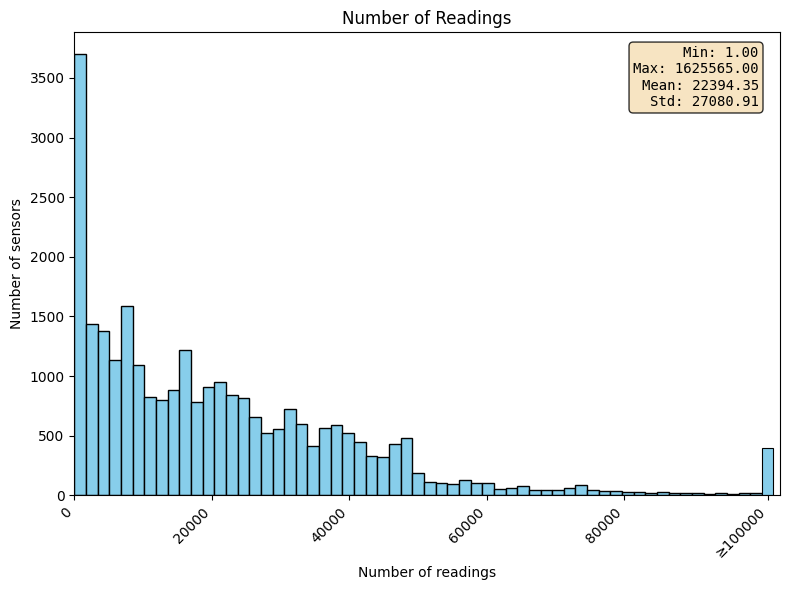

In [143]:
plot_histogram_with_stats(number_of_records, title='Number of Readings', x_range=(0, 1e5), x_label="Number of readings", y_label="Number of sensors")

## Duration
Examine duration of measurements on the meter

In [77]:
def get_datetimes(dates: list) -> list:
    datetime_dates = []
    
    for date in dates:
        try:
            date = pd.to_datetime(date, format='%Y-%m-%d %H:%M:%S')
        except ValueError:
            date = pd.to_datetime(date, format='%Y-%m-%d')
        
        datetime_dates.append(date)
        
    return datetime_dates

In [78]:
start_dates = get_pickle_data('./pickles/start_dates_001.pkl', metadata_to_dict, ['start_time'])
end_dates = get_pickle_data('./pickles/end_dates_001.pkl', metadata_to_dict, ['end_time'])


In [79]:
start_dates = dict(zip(start_dates.keys(), get_datetimes(start_dates.values())))
end_dates = dict(zip(end_dates.keys(), get_datetimes(end_dates.values())))

start_series = pd.Series({k: start_dates[k] for k in start_dates.keys()})
end_series = pd.Series({k: end_dates[k] for k in end_dates.keys()})

durations = end_series - start_series
durations_in_days = durations.dt.total_seconds() / (3600 * 24)

durations_in_days_dict = durations_in_days.to_dict()

In [80]:
print(f"The earliest data is: {min(start_series)}")
print(f"The latest date is: {max(end_series)}")

The earliest data is: 2020-01-01 00:00:01
The latest date is: 2025-10-08 00:00:00


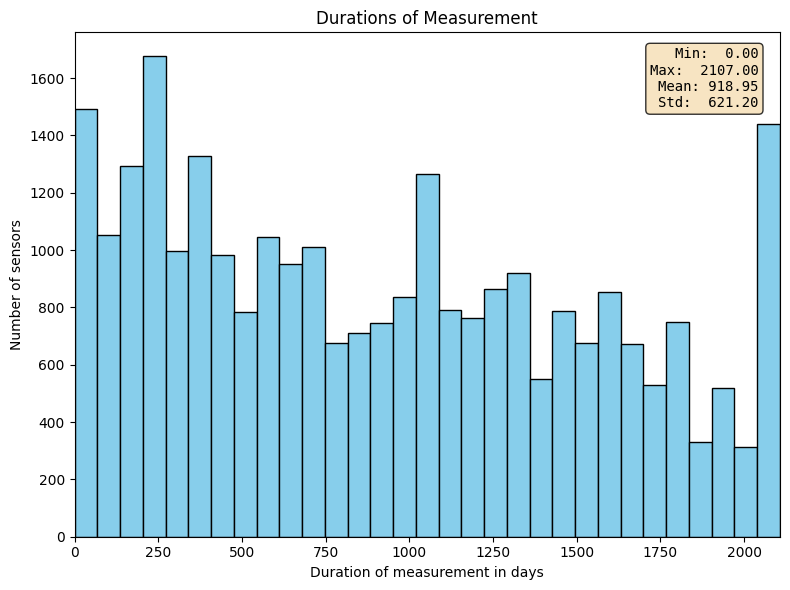

In [149]:
plot_histogram_with_stats_no_overflow(durations_in_days, "Durations of Measurement", x_label="Duration of measurement in days", y_label="Number of sensors")

As we can see, we get many durations. Some lasting less then a year but some over multiple years.

In [82]:
def is_active(end_date) -> bool:
    '''
    Returns True if water meter contains data from September 2025, else False
    '''
    september_date = datetime.strptime("2025-09-01", "%Y-%m-%d")
    return end_date >= september_date

active_meter_filenames = [filename for filename, end_date in end_dates.items() if is_active(end_date)]
print(f"Number of meters that are active as of September 2025: {len(active_meter_filenames)} out of total {len(all_dfs_paths)}")

Number of meters that are active as of September 2025: 24470 out of total 27603


## NaN values in Diff and hodnota

In [83]:
nan_value_counts = get_pickle_data('./pickles/hodnota_nans_001.pkl', metadata_to_dict, ['nan_value_count'])
nan_diff_counts = get_pickle_data('./pickles/diff_nans_001.pkl', metadata_to_dict, ['nan_diff_count'])

In [84]:
filenames_no_nan_hodnota = [filename for filename, nan_count in nan_value_counts.items() if nan_count != 0]
filenames_no_nan_diff = [filename for filename, nan_count in nan_diff_counts.items() if nan_count != 0]
filenames_min5_nan_less_diff = [filename for filename, nan_count in nan_diff_counts.items() if nan_count > 5]

print(f"Number of files that contain NaN values in the Value column; {len(filenames_no_nan_hodnota)}")
print(f"Number of files that contain NaN values in the Diff column; {len(filenames_no_nan_diff)}")
print(f"Number of files that contain more than 5 NaN values in the Diff column; {len(filenames_min5_nan_less_diff)}")

Number of files that contain NaN values in the Value column; 186
Number of files that contain NaN values in the Diff column; 5210
Number of files that contain more than 5 NaN values in the Diff column; 927


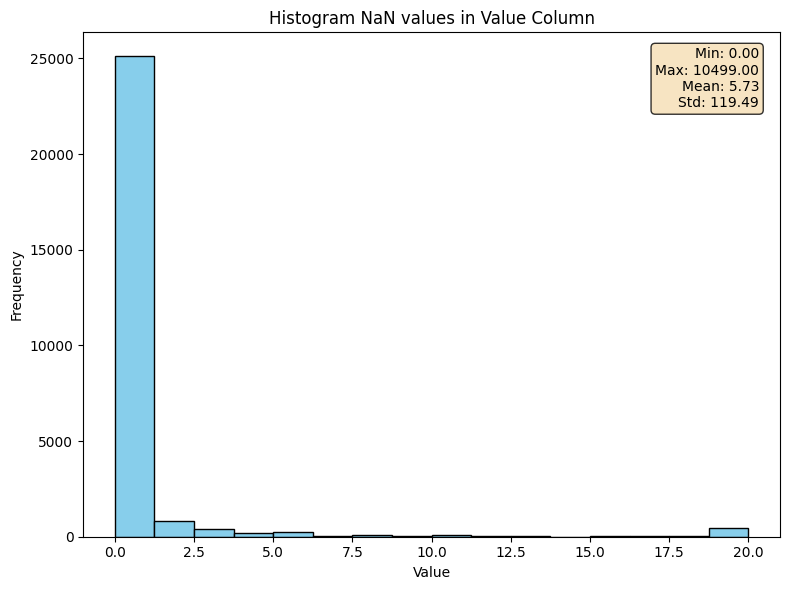

In [85]:
plot_histogram_with_stats(list(nan_diff_counts.values()), "Histogram NaN values in Value Column", x_range=(0, 20)) #some have almost all values nan

Important to note that if diff would be calculated negatively (since new values is lower then prev) we will it with NaN. If we zoom out the histogram we see that some files have almost only nan values

## Periodicity

In [86]:
periodicities = get_pickle_data('./pickles/periodicities_001.pkl', metadata_to_dict, ['common_periodicity_seconds'])
valid_periodicities = {filename: periodicity for filename, periodicity in periodicities.items() if periodicity is not None}

print(f"Number of meters where we could not determine a periodicity: {len(periodicities) - len(valid_periodicities)}")

Number of meters where we could not determine a periodicity: 160


Number of meters that have estimated periodicity over a day: 1049


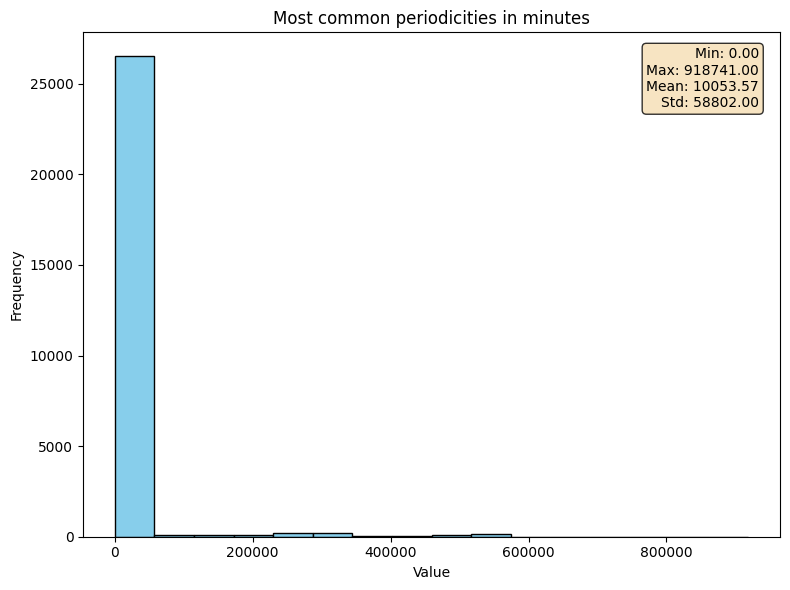

In [87]:
periodicities_in_minutes = [val / 60 for val in valid_periodicities.values()]
periodicities_in_minutes_rounded = [round(val, 0) for val in periodicities_in_minutes]

print(f"Number of meters that have estimated periodicity over a day: {len([p for p in periodicities_in_minutes_rounded if p > (60*24 + 5)])}")

plot_histogram_with_stats(periodicities_in_minutes_rounded, "Most common periodicities in minutes")


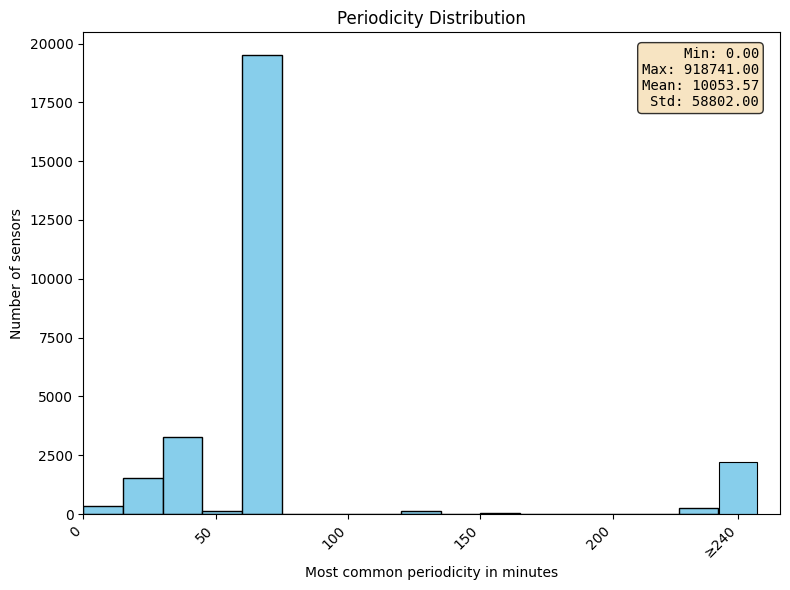

In [146]:
plot_histogram_with_stats(periodicities_in_minutes_rounded, "Periodicity Distribution", x_range=(0, 240), x_label="Most common periodicity in minutes", y_label="Number of sensors")

In [91]:
num_gaps_5min = get_pickle_data('./pickles/gaps_5min_001.pkl', metadata_to_dict, ['num_gaps_5min'])
gaps_10percent = get_pickle_data('./pickles/gaps_10percent_001.pkl', metadata_to_dict, ['num_gaps_10percent'])

valid_num_gaps_5min = {filename: gap_cnt for filename, gap_cnt in num_gaps_5min.items() if filename in valid_periodicities}
valid_num_gaps_10percent = {filename: gap_cnt for filename, gap_cnt in gaps_10percent.items() if filename in valid_periodicities}

In [92]:
print(f"Number of meters that have no gaps over 5 min: {len([g for g in valid_num_gaps_5min.values() if g == 0])}")
print(f"Number of meters that have no gaps over 10 percent of period time: {len([g for g in valid_num_gaps_5min.values() if g == 0])}")

Number of meters that have no gaps over 5 min: 195
Number of meters that have no gaps over 10 percent of period time: 195


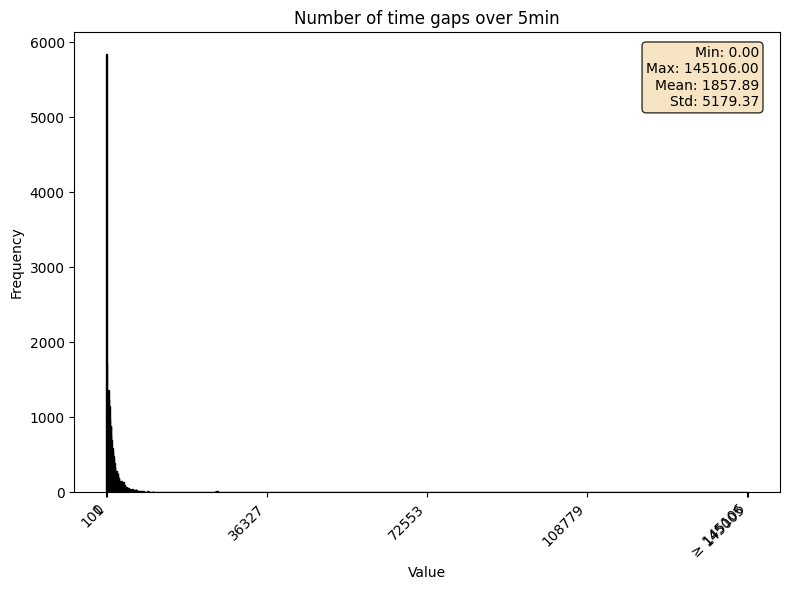

In [93]:
plot_histogram_with_stats(list(valid_num_gaps_5min.values()), "Number of time gaps over 5min")

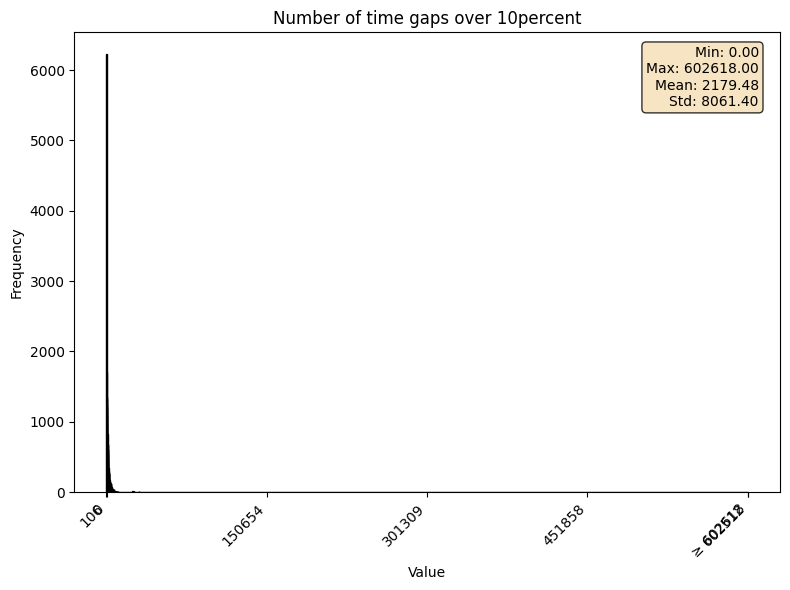

In [94]:
plot_histogram_with_stats(list(valid_num_gaps_10percent.values()), "Number of time gaps over 10percent")

In [95]:
proportion_gaps = get_pickle_data('./pickles/gaps_5min_proportion_001.pkl', metadata_to_dict, ['proportion_of_gaps_5min'])
valid_proportion_gaps = {filename: gap_cnt for filename, gap_cnt in proportion_gaps.items() if filename in valid_periodicities}

In [96]:
print(f"Number of meters that have less then 5 percent of time gaps: {len([g for g in valid_proportion_gaps.values() if g < 0.05])}")

Number of meters that have less then 5 percent of time gaps: 13368


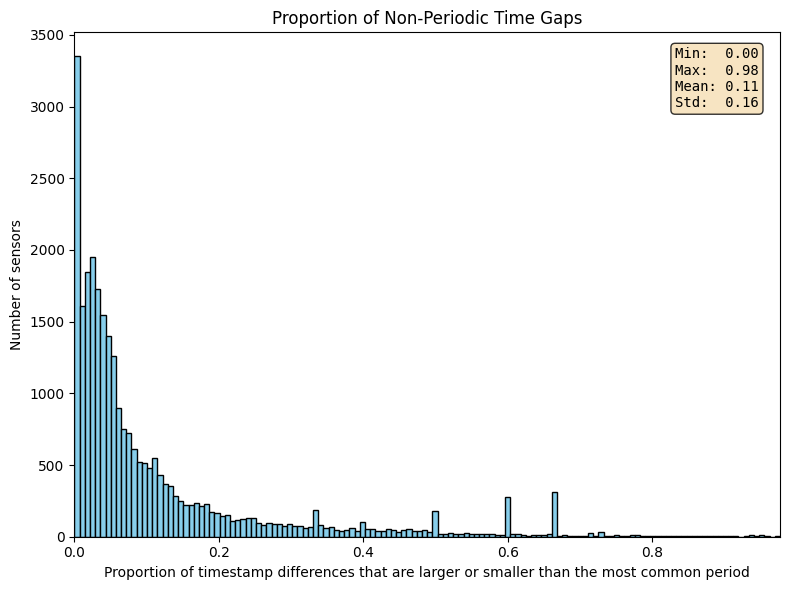

In [154]:
plot_histogram_with_stats_no_overflow(list(valid_proportion_gaps.values()), "Proportion of Non-Periodic Time Gaps", x_label="Proportion of timestamp differences that are larger or smaller than the most common period", y_label="Number of sensors")

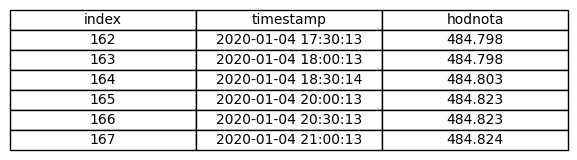

In [98]:
example_df_gaps = pd.read_csv('./data_w_diff_001/2328.csv')
example_df_gaps = example_df_gaps[['timestamp', 'hodnota']]
example_df_gaps = example_df_gaps.iloc[162:168].copy()
#display(example_df_gaps)

df_to_show = example_df_gaps.reset_index()  # index -> column named 'index'

fig, ax = plt.subplots(figsize=(6, 1.5))  # adjust size as needed
ax.axis('off')                           # no axes

tbl = ax.table(
    cellText=df_to_show.values,
    colLabels=df_to_show.columns,
    loc='center',
    cellLoc='center',
    colLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2)

## UpSet Plot

In [158]:
valid_periodicities_under_120min = [filename for filename, periodicity in valid_periodicities.items() if periodicity < (60*60*4 + 5)]
valid_proportion_gaps_under_5percent = [filename for filename, gap in valid_proportion_gaps.items() if gap < 0.25]
filenames_max5_nan_less_diff = [filename for filename, nan_count in nan_value_counts.items() if nan_count < 5]
durations_in_days_over365 = [filename for filename, duration in durations_in_days_dict.items() if duration > 5*7]
#active_meter_filenames

c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\.venv\Lib\site-packages\upsetplot\data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\.venv\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[

<Figure size 1200x700 with 0 Axes>

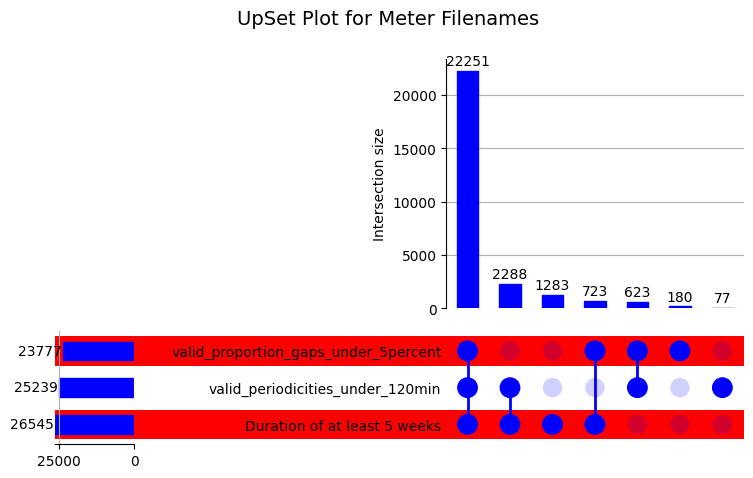

In [160]:
# Create dictionary for UpSet plot input
sets_dict = {
    'valid_periodicities_under_120min': valid_periodicities_under_120min,
    'valid_proportion_gaps_under_5percent': valid_proportion_gaps_under_5percent,
    #'active_meter_filenames': active_meter_filenames,
    #'filenames_max5_nan_less_value': filenames_max5_nan_less_diff,
    'Duration of at least 5 weeks': durations_in_days_over365
}

# Convert to UpSet input format
upset_data = from_contents(sets_dict)

# Create UpSet plot with color customization
fig = plt.figure(figsize=(12, 7))
upset = UpSet(
    upset_data, 
    show_counts='%d', 
    sort_by='cardinality',
    facecolor='blue',           # Blue for intersection bars
    shading_color='red',        # Orange for set size bars
    element_size=40
)
upset.plot()

plt.suptitle('UpSet Plot for Meter Filenames', y=0.98, fontsize=14)
plt.show()

## NaT values
Since timestamp values suffer from time shift from CEST to CET and vice versa. New timestamp column was added called utc_timestamp, however, this timestamp contains some NaT value, when we couldn't infer a certain time value (to infer whether it belonged to CET or CEST).

In [101]:
num_nat_utc_timestamp = get_pickle_data('./pickles/na_timestamp_utc_count.pkl', metadata_to_dict, ['na_timestamp_utc_count'])

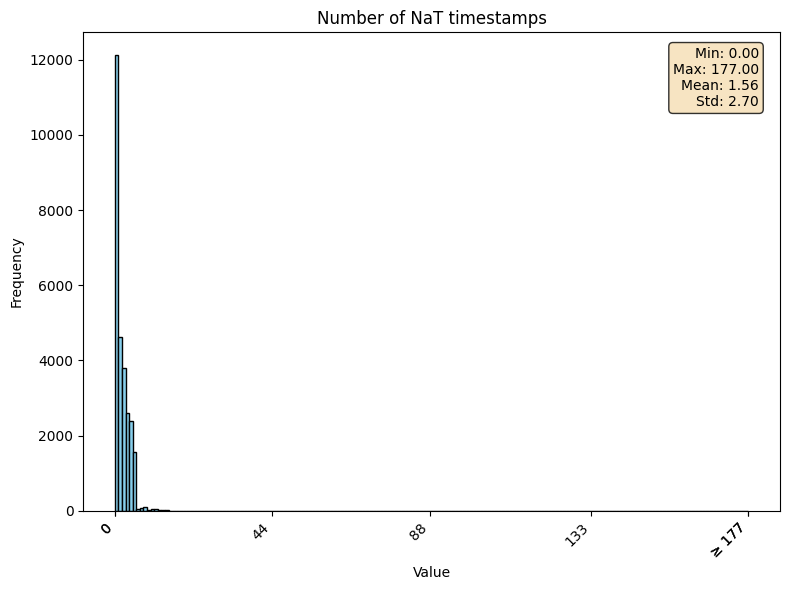

In [102]:
plot_histogram_with_stats(list(num_nat_utc_timestamp.values()), "Number of NaT timestamps")

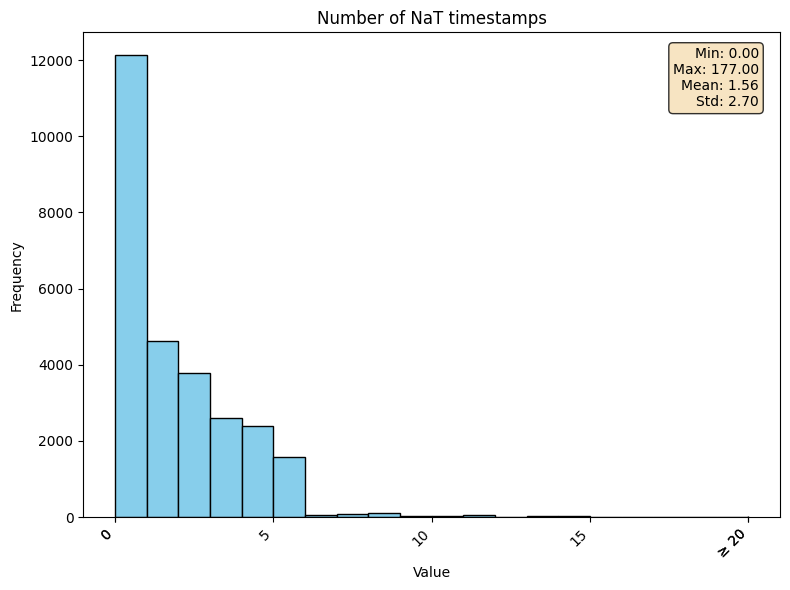

In [103]:
plot_histogram_with_stats(list(num_nat_utc_timestamp.values()), "Number of NaT timestamps", x_range=(0, 20))